# NETBCI 单受试者纵向证据检查

## tl;dr
真实数据仅 sub-1：717 trial、4 session、24 run。表征存在会话差异，CSP 后续预测退化；3 epoch EEGNet 仅完成最小验证。行为只可靠保留 subject/session 成绩向量；run 顺序和分母 unresolved。不存在已验证的人类学习/保持或新算法结论。

## Context & Methods
本 notebook 读取已保存真实执行结果，不再次训练。完整计算在 `scripts/run_netbci_stage1.py`，参数在 `configs/netbci_stage1.json`；代码/数据 SHA 和实际依赖在 analysis receipt。

### Key Assumptions
session 顺序依据研究协议，scans 日期经过匿名化。误差条为条件 run-bootstrap（不是参与者 CI）；几何取样范围为重采样敏感性范围（不是 CI）。同种子重放不是生物学重复。


In [1]:
from pathlib import Path
import json, csv
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if not (ROOT / 'research_logs').exists():
    ROOT = ROOT.parent
AUDIT = ROOT / 'research_logs/netbci_stage1_20261010'
RUN = AUDIT / 'run01'
def table(path):
    with path.open() as f:
        return list(csv.DictReader(f, delimiter='\t'))
results = json.loads((RUN / 'decoder_results.json').read_text())
receipt = json.loads((RUN / 'analysis_receipt.json').read_text())
print({k: receipt[k] for k in ['status','participants','trials','shape','qc_flagged_total']})
plt.rcParams.update({'font.size':11,'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
FIGURES = AUDIT / 'figures'
FIGURES.mkdir(exist_ok=True)


{'status': 'completed_exploratory', 'participants': 1, 'trials': 717, 'shape': [717, 74, 1250], 'qc_flagged_total': 55}


## Data
每个 trial 通过源文件、TSV 行、sample 与原始事件对应；行为表不会广播 trial 标签。

In [2]:
events = table(RUN / 'event_inventory.tsv')
assert len(events) == 717 and len({x['trial_id'] for x in events}) == 717
print('Session trial counts:', {s:sum(x['session']==s for x in events) for s in ['01','02','03','04']})
behavior = table(AUDIT / 'behavior_at_verified_grain.tsv')
assert len(behavior) == 24 and all(x['eeg_run']=='unresolved' for x in behavior)
for s in ['01','02','03','04']:
    scores=[float(x['reported_percentage']) for x in behavior if x['session']==s]
    print(s, 'unweighted mean of six reported percentages:', round(np.mean(scores),3), 'not pooled trial hit rate')


Session trial counts: {'01': 180, '02': 179, '03': 180, '04': 178}
01 unweighted mean of six reported percentages: 73.8 not pooled trial hit rate
02 unweighted mean of six reported percentages: 90.483 not pooled trial hit rate
03 unweighted mean of six reported percentages: 85.083 not pooled trial hit rate
04 unweighted mean of six reported percentages: 89.283 not pooled trial hit rate


## Results
### Frozen-decoder performance
参考模型拟合 120 个源 trial；测试 60/149/150/148。EEGNet 固定 3 epoch，未进行充分训练或目标选参。CSP 后续 constant-rest，50% 的退化区间不代表结果确定。

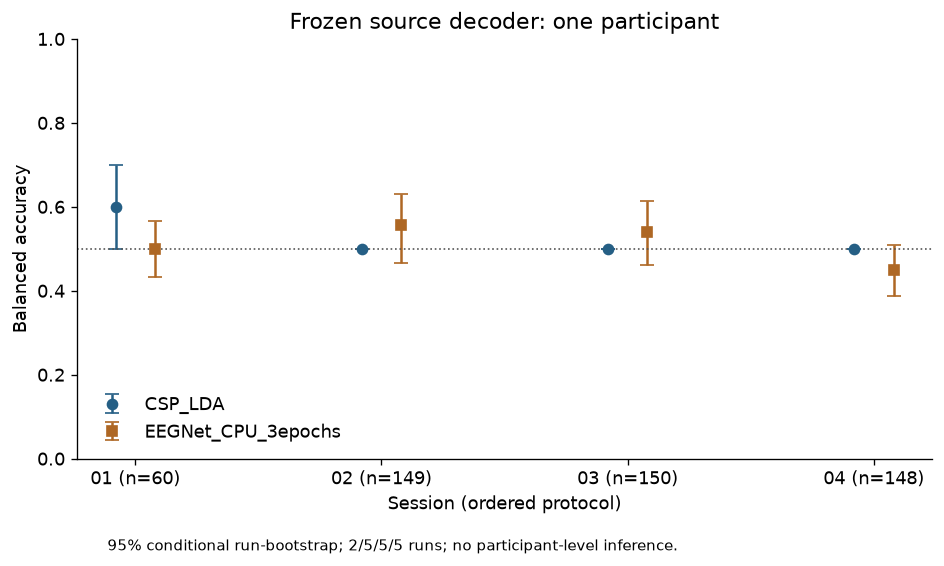

In [3]:
fig, ax = plt.subplots(figsize=(8,4.7))
colors={'CSP_LDA':'#255f85','EEGNet_CPU_3epochs':'#ae6724'}
for family, shift, marker in [('CSP_LDA',-.08,'o'),('EEGNet_CPU_3epochs',.08,'s')]:
    rows=[r for r in results if r['decoder']==family]
    x=np.arange(1,5)+shift
    value=np.array([r['balanced_accuracy'] for r in rows])
    bounds=np.array([r['conditional_run_bootstrap_CI95'] for r in rows])
    ax.errorbar(x,value,yerr=np.array([value-bounds[:,0],bounds[:,1]-value]),fmt=marker,
                capsize=4,color=colors[family],label=family)
ax.axhline(.5,color='#555555',ls=':',lw=1)
ax.set(ylim=(0,1),xticks=[1,2,3,4],xticklabels=['01 (n=60)','02 (n=149)','03 (n=150)','04 (n=148)'],
       ylabel='Balanced accuracy',xlabel='Session (ordered protocol)',title='Frozen source decoder: one participant')
ax.legend(loc='lower left',frameon=False)
fig.text(.12,.01,'95% conditional run-bootstrap; 2/5/5/5 runs; no participant-level inference.',fontsize=9)
fig.tight_layout(rect=(0,.04,1,1))
fig.savefig(FIGURES/'frozen_decoder.png')
plt.show()


### Covariance and PCA sensitivity
所有 session 每 run 每类等取 12 trial，重复 20 个种子。QC 敏感性限共同 run 03–06，每 session 96 trial。QC 是粗筛查，不能保证无伪迹。

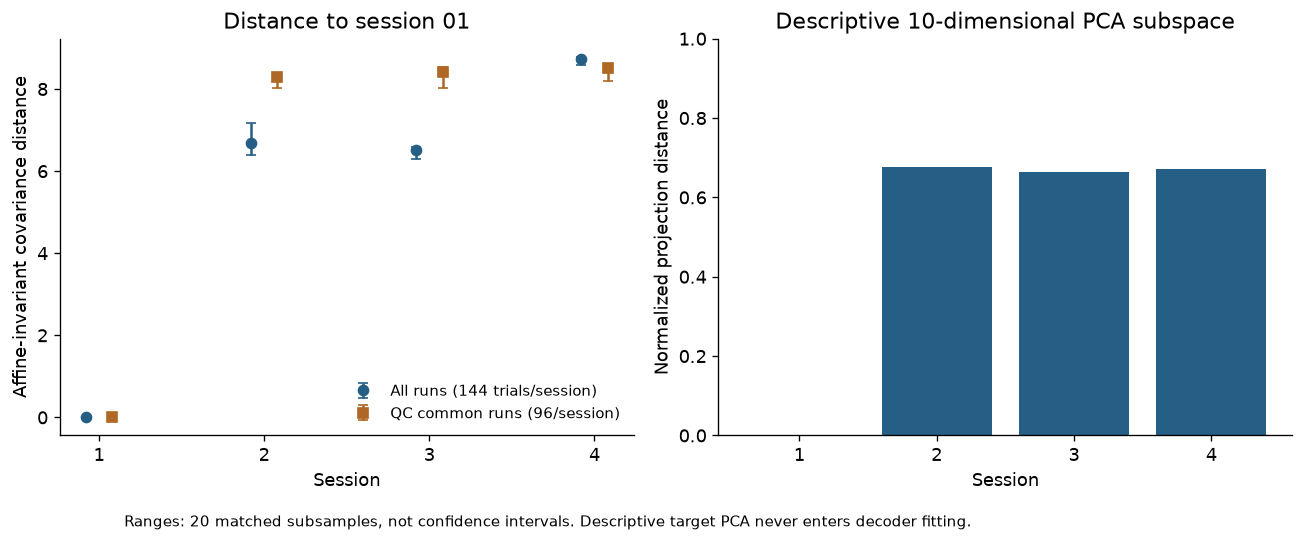

Within-session mean run AIRM distances: [3.328 5.677 3.497 1.764]


In [4]:
full=table(RUN/'matched_geometry.tsv')
clean=table(AUDIT/'sensitivity/qc_matched_geometry.tsv')
fig, axes=plt.subplots(1,2,figsize=(11,4.5))
for rows,label,color,marker,offset in [(full,'All runs (144 trials/session)','#255f85','o',-.08),
                                      (clean,'QC common runs (96/session)','#ae6724','s',.08)]:
    groups=[np.array([float(r['AIRM_to_session01']) for r in rows if r['session']==s]) for s in ['01','02','03','04']]
    means=np.array([g.mean() for g in groups])
    axes[0].errorbar(np.arange(1,5)+offset,means,yerr=[means-np.array([g.min() for g in groups]),np.array([g.max() for g in groups])-means],
                    fmt=marker,capsize=3,label=label,color=color)
axes[0].set(xticks=[1,2,3,4],xlabel='Session',ylabel='Affine-invariant covariance distance',title='Distance to session 01')
axes[0].legend(frameon=False,fontsize=9)
within=[np.mean([float(r['within_session_run_AIRM_mean']) for r in full if r['session']==s]) for s in ['01','02','03','04']]
subspace=[np.mean([float(r['PCA_subspace_distance']) for r in full if r['session']==s]) for s in ['01','02','03','04']]
axes[1].bar(np.arange(1,5),subspace,color='#255f85')
axes[1].set(xticks=[1,2,3,4],ylim=(0,1),xlabel='Session',ylabel='Normalized projection distance',title='Descriptive 10-dimensional PCA subspace')
fig.text(.1,.01,'Ranges: 20 matched subsamples, not confidence intervals. Descriptive target PCA never enters decoder fitting.',fontsize=9)
fig.tight_layout(rect=(0,.04,1,1))
fig.savefig(FIGURES/'representation_sensitivity.png')
plt.show()
print('Within-session mean run AIRM distances:', np.round(within,3))


## Takeaways
1. 计算输出和冻结模型已独立重放，但仅一个参与者，不能判断人群可重复性或 subject-specific variability。
2. 信号差异对 QC/取样/参考敏感；不能直接归因于学习。
3. 固定解码表现是迁移指标，不等同完整的独立控制技能。
4. 下一步确认行为 run 顺序/分母与缺失日志；扩大样本需独立授权。H3/H4 需要受控在线干预和延迟无辅助 probe。

来源：NEMAR nm000305 v1.0.0 (CC BY 4.0)，原始 Dataverse 10.57745/RBJRC7 v2.2。逐文件来源、校验和、日期限制及失败见同目录 JSON/TSV 与仓库文档。
